# # Projeto Prático: Detecção Avançada de Fraudes em Transações Financeiras
**Bootcamp Afya - Automação de Dados com IA**

*Aluna: Anne*

Este notebook apresenta um estudo comparativo (*benchmark*) de diferentes algoritmos de Machine Learning aplicados ao problema de detecção de fraudes em cartões de crédito. O objetivo principal é analisar o impacto do desbalanceamento extremo de classes e avaliar estratégias de modelagem para maximizar o **Recall** (identificação de fraudes reais).

# Importações Globais e Carga dos Dados

In [44]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Scikit-Learn e Ecossistema de Modelagem
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

# Modelos Avançados
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Configurações de visualização globais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

# 1. Carregamento dos dados
print(" Carregando base de dados do TensorFlow...")
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"Dataset carregado! Formato: {df.shape}")
print("\nDistribuição das Classes (0: Normal, 1: Fraude):")
print(df["Class"].value_counts(normalize=True) * 100)

# 2. Engenharia de Variáveis (Apenas uma vez)
df["Amount_log"] = np.log1p(df["Amount"])
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

# 3. Divisão única de Treino e Teste (Removemos 'Time' e 'Amount' original)
X = df.drop(["Class", "Amount", "Time"], axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Dicionário para armazenar as métricas finais de benchmark
resultados_benchmark = {}

print("Dados preparados com sucesso!")

 Carregando base de dados do TensorFlow...
Dataset carregado! Formato: (284807, 31)

Distribuição das Classes (0: Normal, 1: Fraude):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Dados preparados com sucesso!


# Função de Validação Cruzada

In [45]:
def avaliar_modelo_cv(nome_modelo, modelo_instancia):
    print(f"Avaliando {nome_modelo} com StratifiedKFold (3 Splits)...")

    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Medição de Tempo e Métricas por Cross-Validation
    tempo_inicio = time.time()
    cv_results = cross_validate(
        modelo_instancia, X, y,
        cv=cv_strategy,
        scoring=['recall', 'precision', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    tempo_decorrido = time.time() - tempo_inicio

    # Salva as médias no nosso dicionário de resultados
    resultados_benchmark[nome_modelo] = {
        "Recall": round(np.mean(cv_results['test_recall']), 2),
        "Precision": round(np.mean(cv_results['test_precision']), 2),
        "F1-Score": round(np.mean(cv_results['test_f1']), 2),
        "ROC AUC": round(np.mean(cv_results['test_roc_auc']), 2),
        "Tempo de Treino (s)": round(tempo_decorrido, 2)
    }
    print(f"Concluído em {tempo_decorrido:.2f} segundos.")

## Etapa 1: Modelos Lineares e Ensembles Tradicionais
Avaliamos a Regressão Logística (Baseline), o Random Forest com pesos ajustados e o Balanced Random Forest (que faz subamostragem interna para dados desbalanceados).

In [46]:
# 1. Regressão Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
avaliar_modelo_cv("Logistic Regression", lr)

# 2. Random Forest Tradicional
rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)
avaliar_modelo_cv("Random Forest", rf)

# 3. Balanced Random Forest (Especialista em desbalanceamento)
brf = BalancedRandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, sampling_strategy='auto')
avaliar_modelo_cv("Balanced Random Forest", brf)

Avaliando Logistic Regression com StratifiedKFold (3 Splits)...
Concluído em 5.82 segundos.
Avaliando Random Forest com StratifiedKFold (3 Splits)...
Concluído em 201.87 segundos.
Avaliando Balanced Random Forest com StratifiedKFold (3 Splits)...
Concluído em 8.73 segundos.


## Etapa 2: Modelos Avançados de Gradient Boosting (LightGBM e HistGradientBoosting)
Aqui testamos os algoritmos baseados em histogramas, focados em alta velocidade e eficiência com grandes volumes de dados.

In [47]:
# 4. LightGBM Classifier
lgb_peso = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
lgb_model = LGBMClassifier(scale_pos_weight=lgb_peso, random_state=42, verbosity=-1)
avaliar_modelo_cv("LightGBM", lgb_model)

# 5. HistGradientBoosting (Nativo do Scikit-Learn)
hgb_model = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
avaliar_modelo_cv("HistGradientBoosting", hgb_model)

# 6. CatBoost Classifier
cat_model = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)
avaliar_modelo_cv("CatBoost", cat_model)

Avaliando LightGBM com StratifiedKFold (3 Splits)...
Concluído em 20.00 segundos.
Avaliando HistGradientBoosting com StratifiedKFold (3 Splits)...
Concluído em 12.40 segundos.
Avaliando CatBoost com StratifiedKFold (3 Splits)...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Concluído em 206.23 segundos.


## Etapa 3: Otimização de Hiperparâmetros (GridSearchCV no XGBoost)
Utilizamos o `GridSearchCV` para varrer combinações de parâmetros do XGBoost, direcionando o algoritmo para maximizar o **Recall**.

In [50]:
print("🎛️ Iniciando GridSearchCV para o XGBoost (Otimizando Recall)...")
xgb_base = XGBClassifier(eval_metric="logloss", random_state=42)

param_grid = {
   "max_depth": [3, 5],
   "n_estimators": [50, 100],
   "scale_pos_weight": [10, 50]
}

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring="recall", n_jobs=-1
)

grid_search.fit(x_train, y_train)
xgb_otimizado = grid_search.best_estimator_

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

# Avalia o modelo otimizado no ecossistema de Cross Validation
avaliar_modelo_cv("XGBoost (Otimizado)", xgb_otimizado)

🎛️ Iniciando GridSearchCV para o XGBoost (Otimizando Recall)...
Melhores parâmetros encontrados: {'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 50}
Avaliando XGBoost (Otimizado) com StratifiedKFold (3 Splits)...
Concluído em 9.03 segundos.


## Etapa 4: Resultados Consolidados e Explicabilidade (SHAP)
Geramos a tabela comparativa automatizada do nosso Benchmark e abrimos a "caixa-preta" do modelo campeão para entender quais variáveis mais impactam o risco de fraude.


======================================== TABELA COMPARATIVA FINAL ========================================


,Recall,Precision,F1-Score,ROC AUC,Tempo de Treino (s)
Balanced Random Forest,0.91,0.06,0.11,0.98,8.73
HistGradientBoosting,0.86,0.50,0.63,0.97,12.40
LightGBM,0.85,0.03,0.06,0.90,20.00
XGBoost (Otimizado),0.85,0.68,0.75,0.98,9.03
CatBoost,0.83,0.83,0.83,0.98,206.23
Random Forest,0.79,0.87,0.83,0.97,201.87
Logistic Regression,0.62,0.87,0.72,0.98,5.82



 Calculando valores SHAP para os top 300 registros de teste...


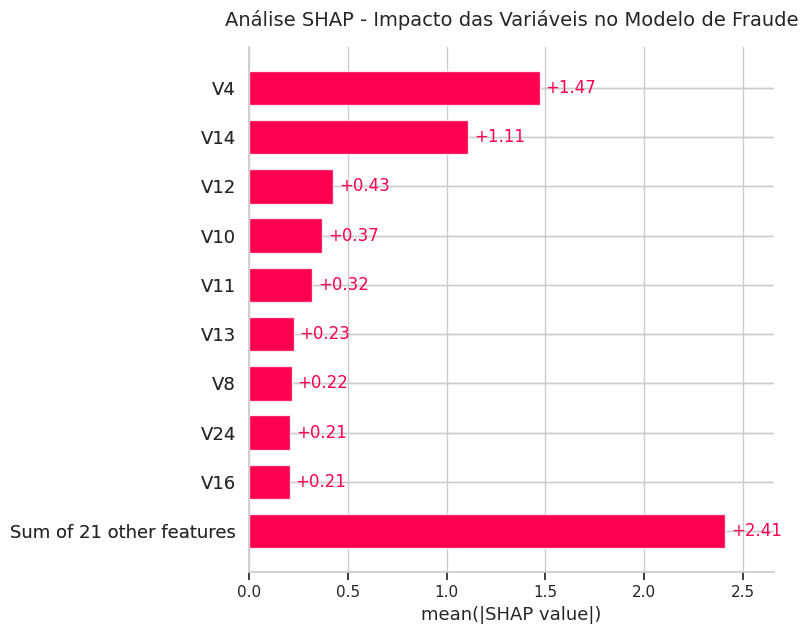

In [51]:
# 1. Gerar e exibir a tabela comparativa
df_benchmark = pd.DataFrame(resultados_benchmark).T
df_benchmark = df_benchmark.sort_values(by="Recall", ascending=False)

print("\n" + "="*40 + " TABELA COMPARATIVA FINAL " + "="*40)
display(df_benchmark)
print("="*106)

# 2. Explicabilidade com SHAP utilizando o XGBoost Otimizado
print("\n Calculando valores SHAP para os top 300 registros de teste...")
explainer = shap.TreeExplainer(xgb_otimizado)
shap_values = explainer(x_test[:300])

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False)
plt.title("Análise SHAP - Impacto das Variáveis no Modelo de Fraude", fontsize=14, pad=15)
plt.tight_layout()
plt.show()